In [1]:
from typing import Dict, List

from model_ranking.results import get_summary_results
from model_ranking.plots import plot_alpha_sweep_specific_norm

# Finetuned Consistency vs Performance

In [2]:
selected_augmentations = {
    "none": [""],
    "DO": ["a0005", "a001", "a005", "a01", "a02", "a03", "a04"],
}

sources = ["EPFL", "Hmito", "Rmito", "VNC"]
targets = ["EPFL", "Hmito", "Rmito"]

data_mapping = {
    "EPFL": "E",
    "Hmito": "H",
    "Rmito": "R",
    "VNC": "V",
}

models = {
    "EtoH": "EtoH_def_new_model1",
    "EtoR": "EtoR_def_new_model1",
    "HtoE": "HtoE_def_new_model1",
    "HtoR": "HtoR_def_new_model1",
    "RtoE": "RtoE_def_new_model1",
    "RtoH": "RtoH_def_new_model1",
    "VtoE": "VtoE_def_new_model1",
    "VtoH": "VtoH_def_new_model1",
    "VtoR": "VtoR_def_new_model1",
}

per_target_norms = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}
result_folders = {
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}
consis_keys = {
    "EPFL": "EI_consis",
    "Hmito": "EI_consis",
    "Rmito": "EI_consis",
    "VNC": "EI_consis",
}
perf_key = "hard_f1"
approach="feature_perturbation_consistency"
consis_postfix="median"
perf_postfix="median"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 21.02it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 17.72it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 20.30it/s]


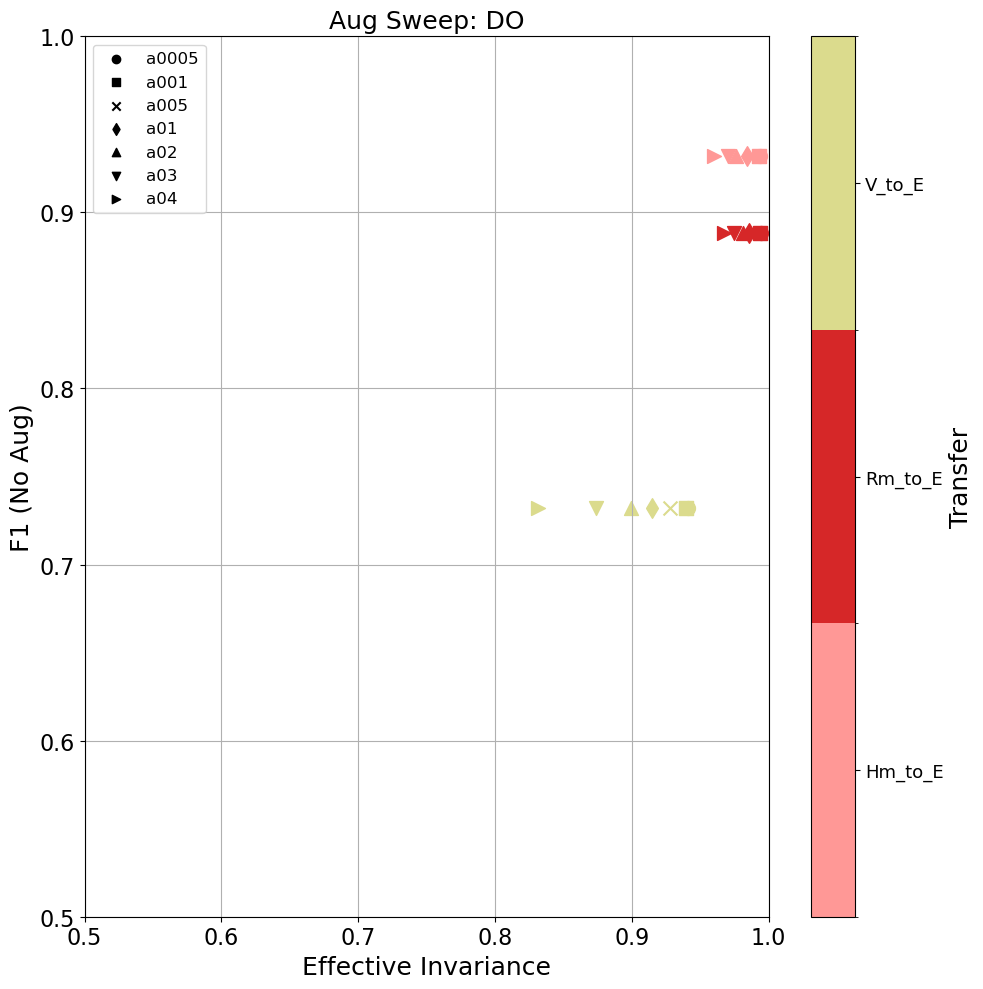

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 12.95it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 21.90it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 17.71it/s]


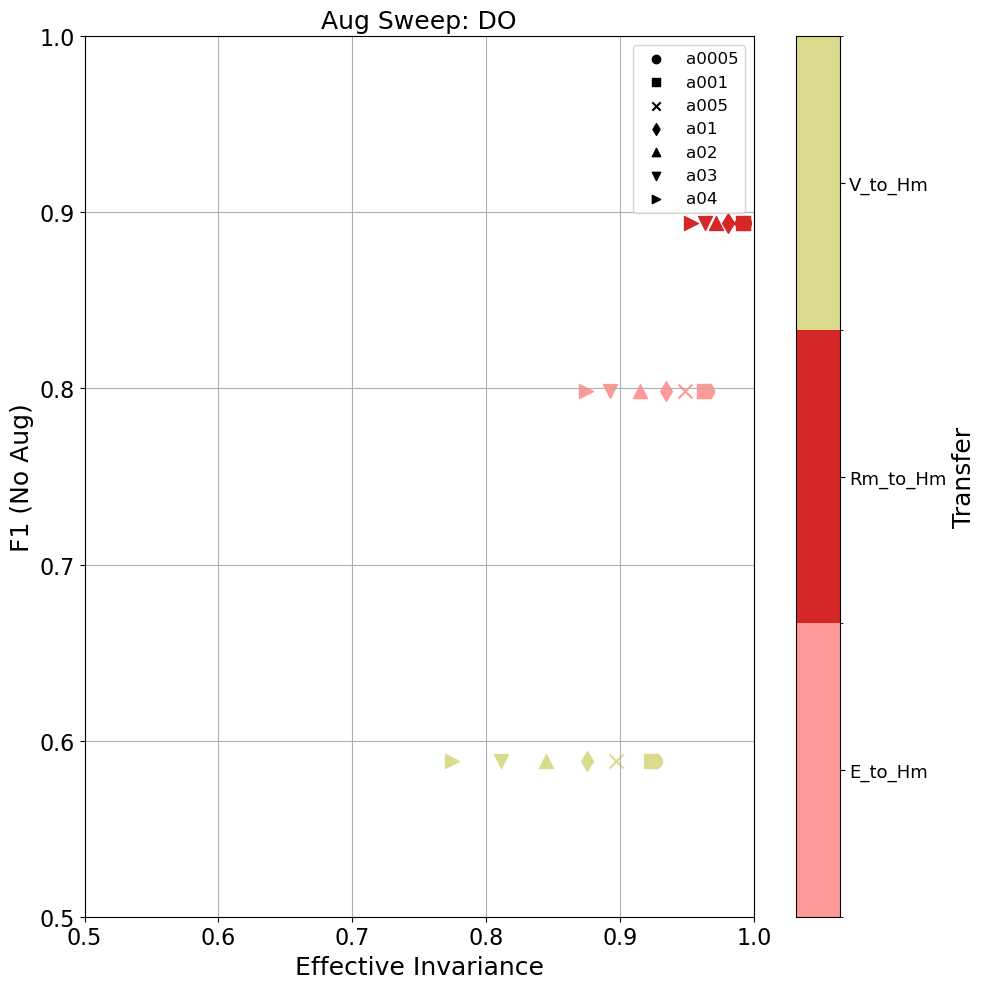

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 18.62it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 22.35it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 22.09it/s]


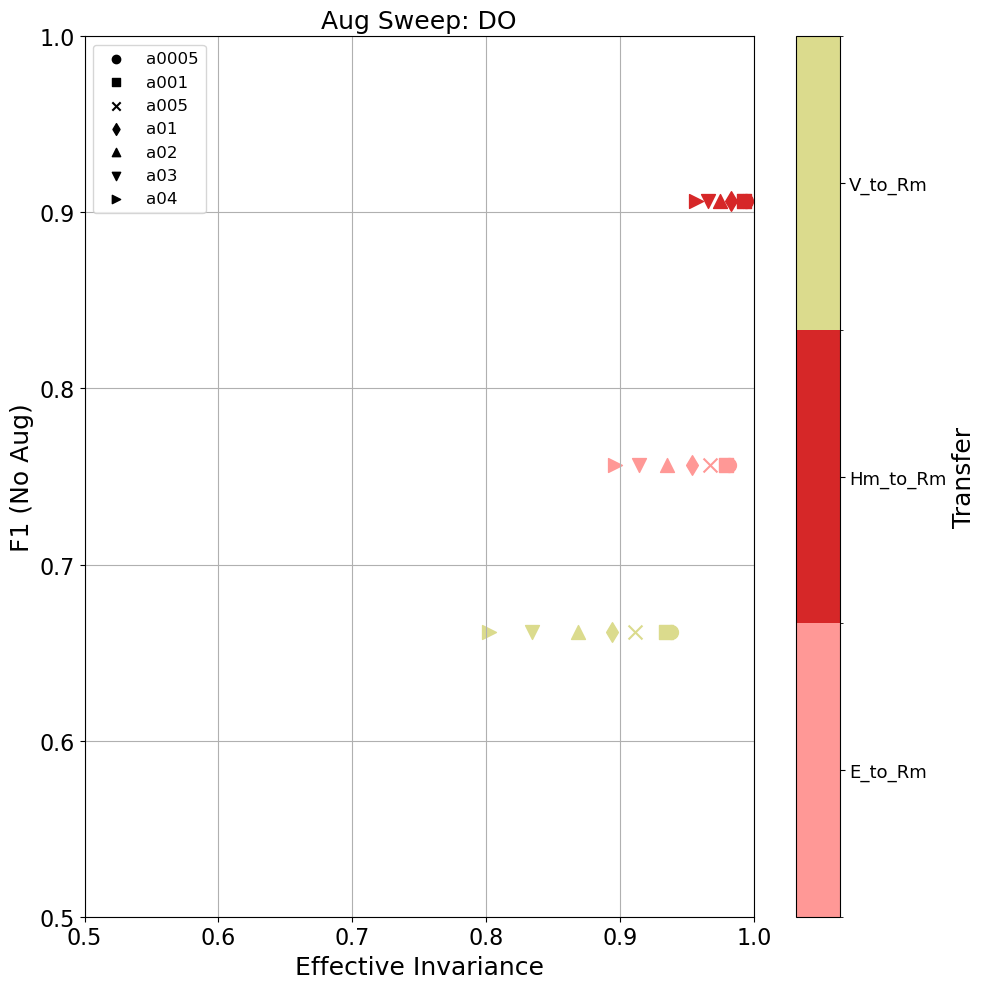

In [3]:
for target in targets:
    source_models: Dict[str, str] = {}
    source_datasets: List[str] = []
    for source in sources:
        if source == target:
            continue
        transfer = f"{data_mapping[source]}to{data_mapping[target]}"
        model = models[transfer]
        source_models[source] = model
        source_datasets.append(source)

    consis_str, _, NA_perf = get_summary_results(
        source_data=source_datasets,
        target_data=[target],
        source_models=source_models,
        selected_augmentations=selected_augmentations,
        selected_norms=per_target_norms,
        consis_keys=consis_keys,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix=consis_postfix,
        perf_postfix=perf_postfix,
        base_seg_dir=base_result_path,
    )
    plot_alpha_sweep_specific_norm(
        consis_str,
        NA_perf,
        augs=["DO"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        xlim=(0.5, 1),
        ylim=(0.5,1),
        n_rows=1,
        n_cols = 1,
    )

In [4]:
NA_perf

{'E_to_Rm': {'norm_Normalize': 0.7565679550170898},
 'Hm_to_Rm': {'norm_Normalize': 0.906495213508606},
 'V_to_Rm': {'norm_Normalize': 0.6615982055664062}}

# Inital Consistency vs Finetuned performance

In [5]:
selected_augmentations = {
    "none": [""],
    "DO": ["a0005", "a001", "a005", "a01", "a02", "a03", "a04"],
}

sources = ["EPFL", "Hmito", "Rmito", "VNC"]
targets = ["EPFL", "Hmito", "Rmito"]

data_mapping = {
    "EPFL": "E",
    "Hmito": "H",
    "Rmito": "R",
    "VNC": "V",
}

finetuned_models = {
    "EtoH": "EtoH_def_new_model1",
    "EtoR": "EtoR_def_new_model1",
    "HtoE": "HtoE_def_new_model1",
    "HtoR": "HtoR_def_new_model1",
    "RtoE": "RtoE_def_new_model1",
    "RtoH": "RtoH_def_new_model1",
    "VtoE": "VtoE_def_new_model1",
    "VtoH": "VtoH_def_new_model1",
    "VtoR": "VtoR_def_new_model1",
}
source_models = {
    "EPFL": "E_model4",
    "Hmito": "Hm_model3",
    "Rmito": "Rm_model3",
    "VNC": "V_model1",
}

per_target_norms = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}
result_folders = {
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}
finetuned_consis_keys = {
    "EPFL": "EI_consis",
    "Hmito": "EI_consis",
    "Rmito": "EI_consis",
    "VNC": "EI_consis",
}
source_consis_keys = {
    "EPFL": "EI_th05",
    "Hmito": "EI_th05",
    "Rmito": "EI_th05",
}

perf_key = "hard_f1"
approach="feature_perturbation_consistency"
finetuned_consis_postfix="median"
source_consis_postfix="median_per_alpha"
perf_postfix="median"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 14.52it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 16.28it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 22.00it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 25.37it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 24.76it/s]


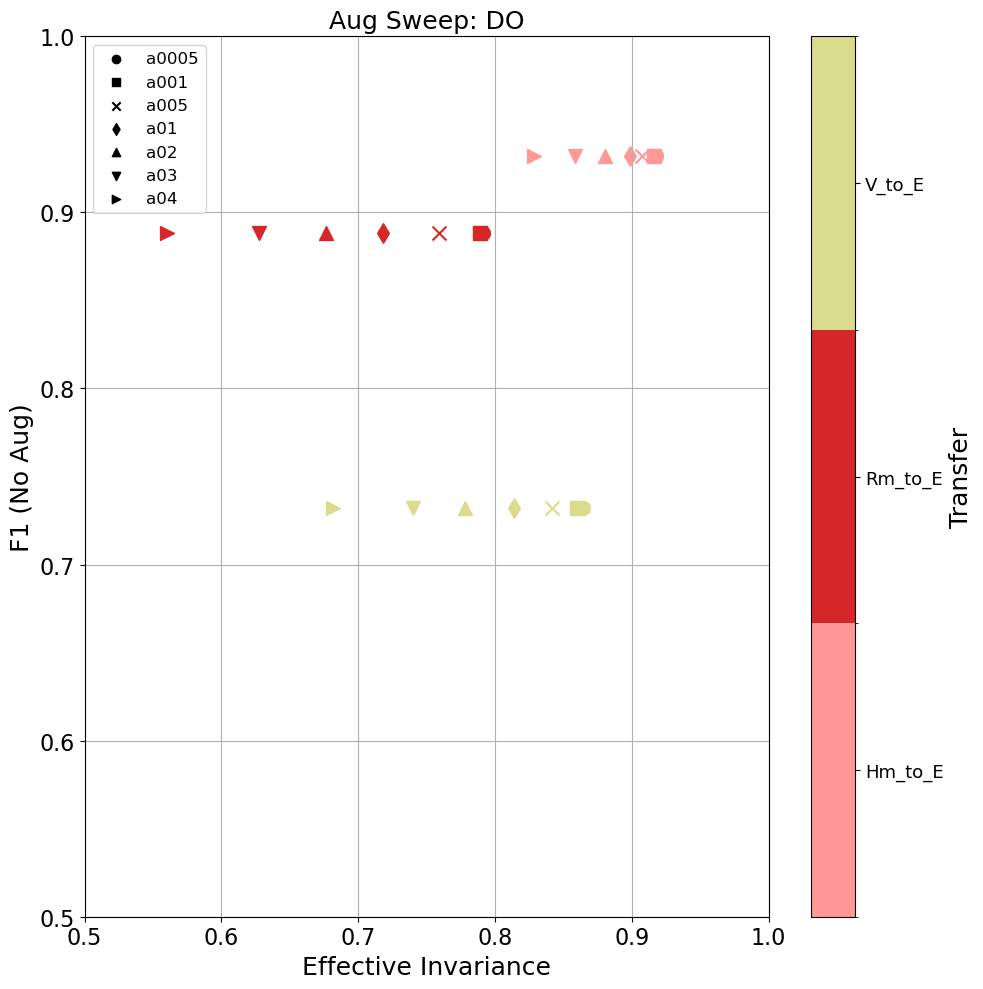

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 14.90it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 16.18it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 22.41it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 26.05it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 21.62it/s]


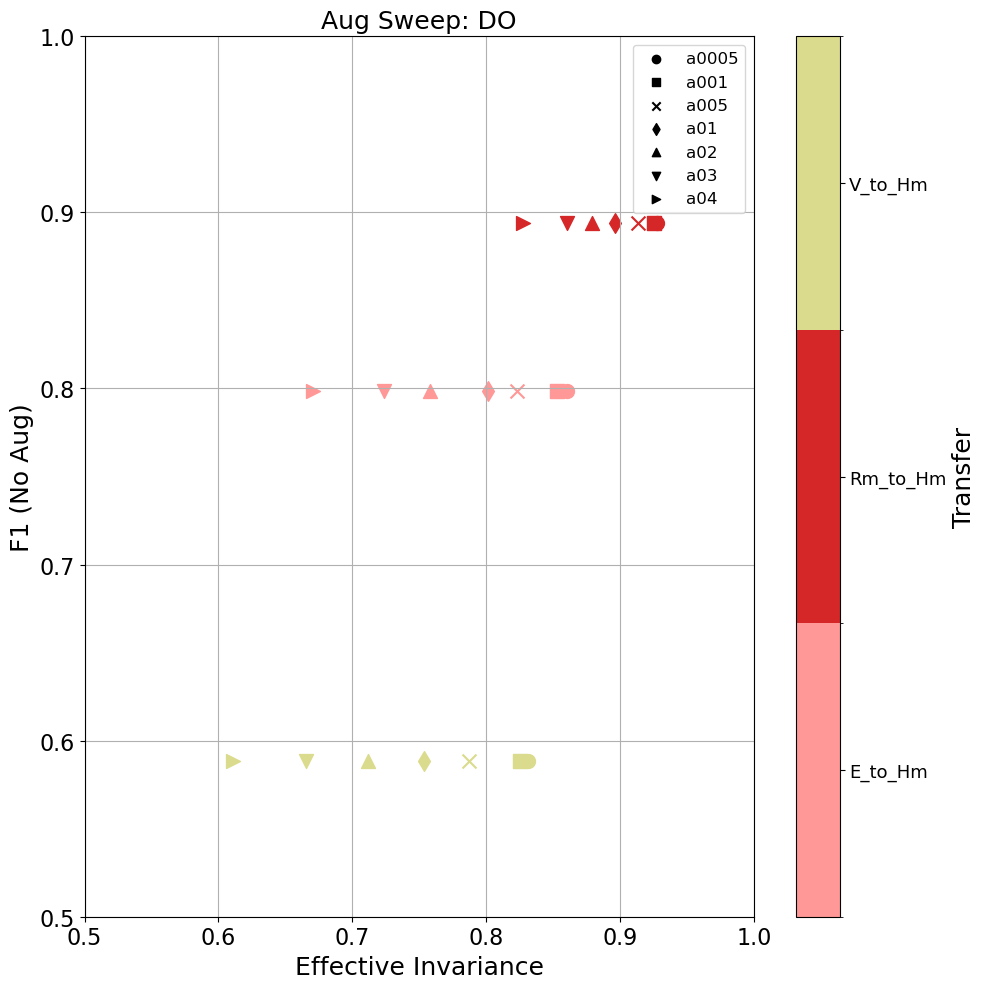

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 16.79it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 19.43it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 23.92it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 24.92it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 25.61it/s]


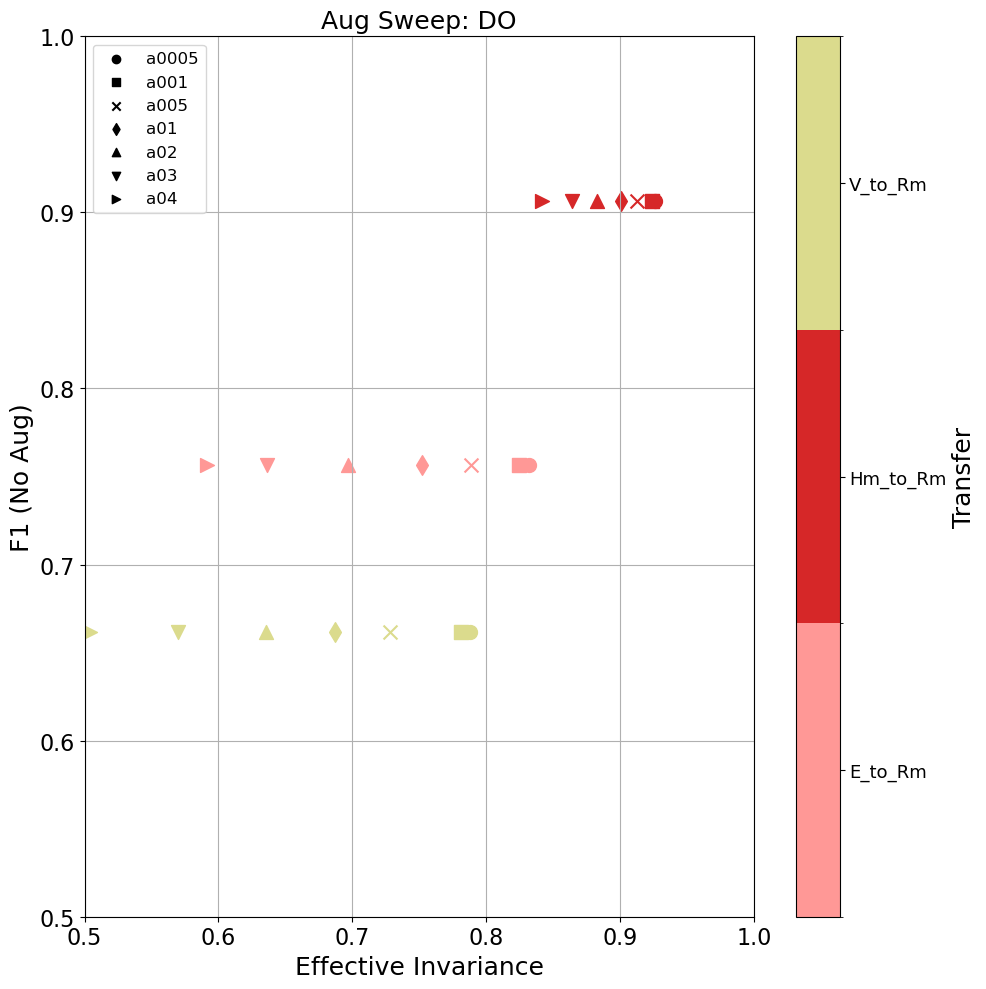

In [6]:
for target in targets:
    consis_str, _, _ = get_summary_results(
        source_data=["EPFL", "Hmito", "Rmito"],
        target_data=[target],
        source_models=source_models,
        selected_augmentations=selected_augmentations,
        selected_norms=per_target_norms,
        consis_keys=source_consis_keys,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix=source_consis_postfix,
        perf_postfix=perf_postfix,
        base_seg_dir=base_result_path,
    )
    consis_str_VNC, _, _ = get_summary_results(
        source_data=["VNC"],
        target_data=[target],
        source_models=source_models,
        selected_augmentations=selected_augmentations,
        selected_norms=per_target_norms,
        consis_keys={
            "EPFL": "EI_consis",
            "Hmito": "EI_consis",
            "Rmito": "EI_consis",
        },
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix=perf_postfix,
        base_seg_dir=base_result_path,
    )
    consis_str.update(consis_str_VNC)
    
    # Finetuned_performance
    per_target_models: Dict[str, str] = {}
    source_datasets: List[str] = []
    for source in sources:
        if source == target:
            continue
        transfer = f"{data_mapping[source]}to{data_mapping[target]}"
        model = finetuned_models[transfer]
        per_target_models[source] = model
        source_datasets.append(source)

    _, _, finetuned_NA_perf = get_summary_results(
        source_data=source_datasets,
        target_data=[target],
        source_models=per_target_models,
        selected_augmentations=selected_augmentations,
        selected_norms=per_target_norms,
        consis_keys=consis_keys,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix=consis_postfix,
        perf_postfix=perf_postfix,
        base_seg_dir=base_result_path,
    )

    plot_alpha_sweep_specific_norm(
        consis_str,
        finetuned_NA_perf,
        augs=["DO"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        xlim=(0.5, 1),
        ylim=(0.5,1),
        n_rows=1,
        n_cols = 1,
    )